# Develop quick stuff

For temporary/quick stuff to be developed

In [3]:
import os
import sys

base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)

from IPython.display import display, Markdown
import torch

from thesis.helper_scripts.general import extract_all_sim_objs, extract_biases_and_corrs_from_dirnames
from thesis.helper_scripts.sensitivity_analysis import extract_bayes_errors
from thesis.helper_scripts.hypothesis_visualization import (
  plot_lines_and_mains,
  generate_lines_for_diffs,
  gen_lines_from_diff_dict,
  construct_all_diffs_tensor,
  get_areas,
  normalize_areas,
  plot_heatmap_grid,
  wrapper_plot_grid_of_diffs_between_logit_and_acc,
  plot_acc_rates_per_round
)

from experiments.acceptance_loop_cv_based_MNAR import THRESHOLD_BASIS, METRIC_CATEGORIES
from berebasl.simulation.credit_data_simulation import CreditDataGenerator, GaussianMixture

print()

real_order =  []

for th in THRESHOLD_BASIS:
  for m in METRIC_CATEGORIES:
    real_order.append(th + '_' + m )

all_acc_vector_names = [th + '_' + m for th in THRESHOLD_BASIS for m in METRIC_CATEGORIES]

print(real_order, all_acc_vector_names)


['oracle_ks', 'oracle_roc', 'acc_based_ks', 'acc_based_roc'] ['oracle_ks', 'oracle_roc', 'acc_based_ks', 'acc_based_roc']


In [4]:
grid_path = '../berebasl/data/simulations/mnar_grid_hyp_testing'

grid_biases, grid_corrs = extract_biases_and_corrs_from_dirnames(grid_path)
grid_biases = dict(sorted(grid_biases.items(), key=lambda x: x[1]))
grid_corrs = dict(sorted(grid_corrs.items(), key=lambda x: x[1]))
all_sim_objs = extract_all_sim_objs(grid_path, grid_biases, grid_corrs)
base_sim_objs = all_sim_objs['0_0']['0_0']

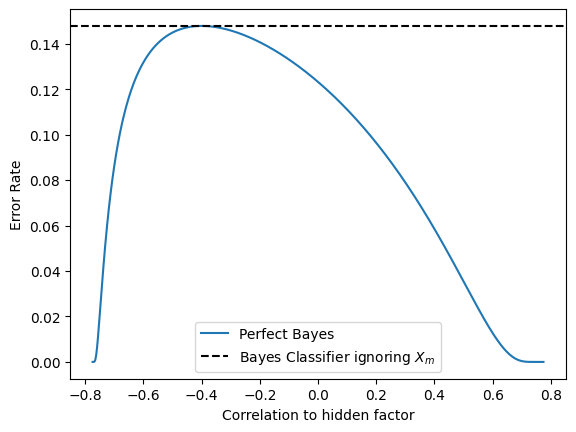

In [ ]:
from matplotlib import pyplot as plt
from experiments.acceptance_loop_cv_based_MNAR import joint_mnar_default_dgp, mnar_default_dgp

corrs = torch.linspace(-0.7745966, 0.7745966, steps=500) # min and max corrs where still non singular and positive definite
dgp_all_corrs = joint_mnar_default_dgp(
    seed_credit_data_gen=1807,
    var_to_hide=base_sim_objs["var_to_hide"],
    hidden_corrs=corrs,
    deterministic_weights_for_mixture_sampling=False,
    device='cpu',
    dtype=torch.float32
)

bayes_errors = extract_bayes_errors(all_sim_objs, grid_biases, grid_corrs)

bayes_err_ignoring_var = bayes_errors[0,0,1].item()

bayes_errs_full = dgp_all_corrs.bayes_error_under_equal_covs()
plt.plot(corrs, bayes_errs_full, label="Perfect Bayes")
plt.axhline(
    y=bayes_err_ignoring_var,
    label="Bayes Classifier ignoring $X_m$",
    ls = "--",
    c="k"
)
plt.xlabel("Correlation to hidden factor")
plt.ylabel("Error Rate")

plt.legend()
plt.show()

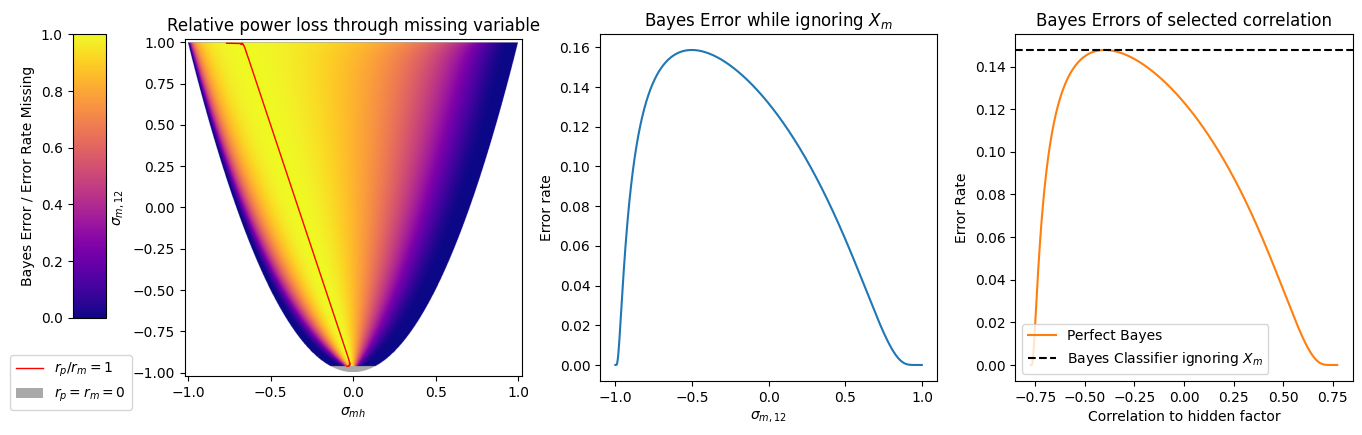

In [ ]:
cax.figure

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

import matplotlib as mpl
from math import sqrt

def _dummy_default_dgp(dtype=torch.float32) -> CreditDataGenerator:
    return mnar_default_dgp(
            seed_credit_data_gen=1807,
            var_to_hide=-1,
            hidden_corr=0,
            deterministic_weights_for_mixture_sampling=False,
            device='cpu',
            dtype=torch.float32
        )

def corr_space_grid(corr_space: torch.Tensor):
    """
    Builds the (A,B) correlation grid.

    Returns
    -------
    A : Tensor
        Grid of σ_{m,12}.
    B : Tensor
        Grid of σ_{mh}.
    comb_AB : Tensor
        [...,2] tensor with (A,B) coordinates.
    """
    A, B = torch.meshgrid(corr_space.flip(0), corr_space, indexing="ij")
    comb_AB = torch.stack([A, B], dim=-1)
    return A, B, comb_AB

def extract_full_information_boundary(
    corr_space: torch.Tensor,
    normalized_relative_errors: torch.Tensor,
):
    """
    Returns the coordinates where the Bayes error of the reduced
    model equals the error of the full model
    """
    max_vals, max_inds = normalized_relative_errors.nan_to_num(-20).max(dim=-1)

    _, _, corr_space_grid = corr_space_grid(corr_space)

    coords_highest = corr_space_grid[
        torch.arange(corr_space_grid.size(0)),
        max_inds
    ]

    return coords_highest[max_vals == 1]


def calc_all_permissible_bayes_err(max_corrs: int, encoding_no_hidden_was_zero: float | int, var_to_hide: int):
    assert encoding_no_hidden_was_zero < 0
    corr_space = torch.linspace(-1, 1, max_corrs+2)[1:-1]
    A, B, comb_AB = corr_space_grid(corr_space)

    mask_valid_AB = B.square() < (1+A)/2
    valid_A_B = comb_AB[mask_valid_AB]

    dgp_for_canvass = _dummy_default_dgp()

    F = dgp_for_canvass.F
    V = valid_A_B.size(0)
    covs = dgp_for_canvass.good_mixture.cov_chol_decomp.new_ones(V, F, F)

    covs[:, [0, 1], [1,0]] = valid_A_B[:, 0].unsqueeze(-1)
    covs[:, [0,1,2, 2], [2,2,0,1]] = valid_A_B[:, 1].unsqueeze(-1)

    assert not torch.all(covs[0] == covs[1:], dim=(-2, -1)).any()

    vars_to_take_over = {
        vn : getattr(dgp_for_canvass, vn) for vn in [
                "prob_bad_given_no_shock",
                "prob_idiosyncratic_shock",
                "prob_bad_given_shock",
                "feats_noise_var"
            ]
    }

    dgp_with_all_valid = CreditDataGenerator(
        bad_mixture=GaussianMixture(
            mean=dgp_for_canvass.bad_mixture.mean.expand(V, F),
            cov=covs
        ),
        good_mixture=GaussianMixture(
            mean=dgp_for_canvass.good_mixture.mean.expand(V, F),
            cov=covs.clone()
        ),
        **vars_to_take_over
    )

    bayes_error_full_valids = dgp_with_all_valid.bayes_error_under_equal_covs()
    bayes_error_no_hidden_valids = dgp_with_all_valid.bayes_error_under_equal_covs(hidden_vars=[var_to_hide])

    assert torch.all(bayes_error_full_valids <= bayes_error_no_hidden_valids) # Must always be

    encoding_no_hidden_was_zero = -1

    relative_bayes_error = bayes_error_full_valids / bayes_error_no_hidden_valids
    relative_bayes_error.masked_fill_(bayes_error_no_hidden_valids==0, encoding_no_hidden_was_zero)


    normalized_relative_errors = torch.full_like(A, fill_value=float('nan'), dtype=relative_bayes_error.dtype)
    normalized_relative_errors[mask_valid_AB] = relative_bayes_error

    idxs_first_appearence_unique_corr_mh = torch.nn.functional.pad(mask_valid_AB.sum(dim=-1).cumsum(dim=-1)[:-1], pad=(1,0), value=0)
    bayes_err_no_hidden_valids_per_corr = bayes_error_no_hidden_valids[idxs_first_appearence_unique_corr_mh]

    return normalized_relative_errors, corr_space, bayes_err_no_hidden_valids_per_corr

def build_cmap_for_normalized_relative_errors(normalized_relative_errors: torch.Tensor):
    """
    This method does not require norming as errors are already normed in [0,1]
    """
    uniques = normalized_relative_errors.nan_to_num(nan=-float('inf')).unique(sorted=True)[1:]
    expected_to_be_dummy = uniques[0]
    assert expected_to_be_dummy < 0
    # --- 1. Build a continuous colormap from blue to red ---
    cmap = mpl.colormaps["plasma"]

    cmap.set_bad("white")
    cmap.set_over("green")
    cmap.set_under("darkgray")

    return cmap

def get_bayes_err_comp_under_default_corr_mh(max_corrs: int, var_to_hide: int):
    dgp_for_canvass = _dummy_default_dgp()
    orig_corr_mh = dgp_for_canvass.good_mixture.cov[0,1]

    max_b = sqrt((1+orig_corr_mh)/2)
    corrs = torch.linspace(-max_b, max_b, steps=max_corrs+2)[1:-1] # min and max corrs where still non singular and positive definite
    dgp_all_corrs = joint_mnar_default_dgp(
        seed_credit_data_gen=1807,
        var_to_hide=var_to_hide,
        hidden_corrs=corrs,
        deterministic_weights_for_mixture_sampling=False,
        device='cpu',
        dtype=torch.float32
    )

    bayes_err_ignoring_var = dgp_for_canvass.bayes_error_under_equal_covs([var_to_hide]).item()

    bayes_errs_full = dgp_all_corrs.bayes_error_under_equal_covs()

    return corrs, bayes_errs_full, bayes_err_ignoring_var


def heatmap_plot_relative_errors(cax, ax, ax_legend_extra_cols, normalized_relative_errors, corr_space):
    # --- Colorbar axis (leftmost) ---
    cmap = build_cmap_for_normalized_relative_errors(normalized_relative_errors)

    im = ax.imshow(
        normalized_relative_errors.numpy(),
        cmap,
        norm=mpl.colors.Normalize(vmin=0, vmax=1, clip=False),
        extent=[corr_space[0], corr_space[-1]]*2)

    shift = 0.02
    corrs_lims_map = [-1 - shift, 1 + shift]
    ax.set_xlim(*corrs_lims_map)
    ax.set_ylim(*corrs_lims_map)

    coords_highest_high_enough = extract_full_information_boundary(corr_space, normalized_relative_errors)

    ax.plot(
        coords_highest_high_enough[:, 1],
        coords_highest_high_enough[:, 0],
        c = 'red',
        lw=1,
        label="$P_e^*/P_e^m= 1$"
    )

    handles, legends = ax.get_legend_handles_labels()
    below_patch = Patch(
        facecolor=cmap(-1),
    )

    ax.set_ylabel(r"$\sigma_{m,12}$")
    ax.set_xlabel(r"$\sigma_{mh}$")
    ax.set_title("Relative power loss through missing variable")


    # attach colorbar to the dedicated axis
    cb = cax.figure.colorbar(im, cax=cax)
    # Move ticks + label to the left
    cb.ax.yaxis.set_label_position("left")
    cb.ax.yaxis.tick_left()
    cb.ax.yaxis.set_ticks_position("left")

    ax_legend_extra_cols.axis('off')

    ax_legend_extra_cols.legend(
        handles + [below_patch],
        legends + ["$P_e^*=P_e^m= 0$"],
        loc="center",
        bbox_to_anchor=(-0.05, -0.06),
        #ncol=2
    )

    cb.set_label("$P_e^*/P_e^m$")

def plot_bayes_error_constrained_model(ax, corr_space, bayes_err_no_hidden_valids_per_corr, sigma_mh: float):
    ax.plot(corr_space, bayes_err_no_hidden_valids_per_corr, c=mpl.colormaps["tab10"](0))
    ax.set_xlabel(r"$\sigma_{m,12}$")
    ax.set_ylabel(r"Error rate")
    ax.set_title("Bayes Error while ignoring $X_m$")

def plot_bayes_error_comp_of_selected(ax, corrs, bayes_errs_full, sigma_mh: float):
    ax.plot(corrs, bayes_errs_full, c=mpl.colormaps["tab10"](1), label="Perfect Bayes")
    ax.axhline(
        y=bayes_err_ignoring_var,
        label="Bayes Classifier ignoring $X_m$",
        ls = "--",
        c="k"
    )
    ax.set_xlabel("Correlation to hidden factor")
    ax.set_ylabel("Error Rate")
    ax.set_title(f"$P^m_e | \\sigma_{{m, 12}} = {sigma_mh}$")
    ax.legend()

In [ ]:
max_corrs = 1000

normalized_relative_errors, corr_space, bayes_err_no_hidden_valids_per_corr = calc_all_permissible_bayes_err(
    max_corrs=max_corrs,
    encoding_no_hidden_was_zero=-1,
    var_to_hide=base_sim_objs['var_to_hide']
)

corrs, bayes_errs_full, bayes_err_ignoring_var = get_bayes_err_comp_under_default_corr_mh(max_corrs, base_sim_objs['var_to_hide'])

fig = plt.figure(figsize=(16, 4.5))
gs = GridSpec(nrows=2, ncols=4, height_ratios=[0.9,0.1], width_ratios=[0.1, 1, 1, 1], wspace=0.3, left=0.1)

heatmap_plot_relative_errors(
    cax = fig.add_subplot(gs[0,0]),
    ax=fig.add_subplot(gs[:, 1]),
    ax_legend_extra_cols=fig.add_subplot(gs[1,0]),
    normalized_relative_errors=normalized_relative_errors,
    corr_space=corr_space
)

plot_bayes_error_constrained_model(fig.add_subplot(gs[:, 2]), corr_space, bayes_err_no_hidden_valids_per_corr)

plot_bayes_error_comp_of_selected(fig.add_subplot(gs[:, 3]), corrs, bayes_errs_full, sigma_mh = base_sim_objs['data_generator'].good_mixture.cov[0,1].item())




NameError: name 'heatmap_plot_relative_errors' is not defined

<Figure size 1600x450 with 0 Axes>